# **STOCK NEWS PREDICTION - MODEL TRAINING & EVALUATION**

### **Project Details**
* **Course:** Introduction to Data Science (IDS)
* **Dataset:** Combined DJIA News Dataset
* **Purpose:** Train and evaluate multiple Machine Learning models to predict stock market trends.


### IMPORTS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("MODEL TRAINING & EVALUATION")
print("="*80)
print("✅ All libraries imported!")


MODEL TRAINING & EVALUATION
✅ All libraries imported!


### LOAD PREPROCESSED DATA

In [2]:
print("\n" + "="*80)
print("LOADING PREPROCESSED DATA")
print("="*80)

# Load training and testing data
X_train = np.load('../data/processed/X_train_scaled.npy')
X_test = np.load('../data/processed/X_test_scaled.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')

print(f"✅ Data loaded successfully!")
print(f"\n📊 Data shapes:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test: {y_test.shape}")

print(f"\n📊 Target distribution:")
print(f"   Training - Label 0: {np.sum(y_train == 0)} | Label 1: {np.sum(y_train == 1)}")
print(f"   Testing  - Label 0: {np.sum(y_test == 0)} | Label 1: {np.sum(y_test == 1)}")



LOADING PREPROCESSED DATA
✅ Data loaded successfully!

📊 Data shapes:
   X_train: (1591, 511)
   X_test: (398, 511)
   y_train: (1591,)
   y_test: (398,)

📊 Target distribution:
   Training - Label 0: 739 | Label 1: 852
   Testing  - Label 0: 185 | Label 1: 213


### DEFINE MODELS

In [7]:
print("\n" + "="*80)
print("DEFINING MODELS")
print("="*80)

# Dictionary of models to train
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

print(f"✅ {len(models)} models defined:")
for i, name in enumerate(models.keys(), 1):
    print(f"   {i}. {name}")



DEFINING MODELS
✅ 5 models defined:
   1. Logistic Regression
   2. Random Forest
   3. Gradient Boosting
   4. Decision Tree
   5. SVM


### TRAIN AND EVALUATE ALL MODELS

In [8]:
print("\n" + "="*80)
print("TRAINING AND EVALUATING MODELS")
print("="*80)

# Store results
results = []

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print('='*60)
    
    # Train model
    print("⏳ Training...")
    model.fit(X_train, y_train)
    print("✅ Training complete!")
    
    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    
    print(f"\n📊 Results:")
    print(f"   Accuracy:  {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False)

print("\n" + "="*80)
print("ALL MODELS TRAINED!")
print("="*80)



TRAINING AND EVALUATING MODELS

Training: Logistic Regression
⏳ Training...
✅ Training complete!

📊 Results:
   Accuracy:  0.5075
   Precision: 0.5427
   Recall:    0.5070
   F1-Score:  0.5243

Training: Random Forest
⏳ Training...
✅ Training complete!

📊 Results:
   Accuracy:  0.4925
   Precision: 0.5211
   Recall:    0.6385
   F1-Score:  0.5738

Training: Gradient Boosting
⏳ Training...
✅ Training complete!

📊 Results:
   Accuracy:  0.4950
   Precision: 0.5236
   Recall:    0.6244
   F1-Score:  0.5696

Training: Decision Tree
⏳ Training...
✅ Training complete!

📊 Results:
   Accuracy:  0.5075
   Precision: 0.5378
   Recall:    0.5681
   F1-Score:  0.5525

Training: SVM
⏳ Training...
✅ Training complete!

📊 Results:
   Accuracy:  0.5101
   Precision: 0.5328
   Recall:    0.6854
   F1-Score:  0.5996

ALL MODELS TRAINED!


### DISPLAY RESULTS TABLE

In [9]:
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

print("\n📊 Performance Metrics (Sorted by Accuracy):")
print(results_df.to_string(index=False))

print(f"\n🏆 Best Model: {results_df.iloc[0]['Model']}")
print(f"   Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")


MODEL COMPARISON

📊 Performance Metrics (Sorted by Accuracy):
              Model  Accuracy  Precision   Recall  F1-Score
                SVM  0.510050   0.532847 0.685446  0.599589
Logistic Regression  0.507538   0.542714 0.507042  0.524272
      Decision Tree  0.507538   0.537778 0.568075  0.552511
  Gradient Boosting  0.494975   0.523622 0.624413  0.569593
      Random Forest  0.492462   0.521073 0.638498  0.573840

🏆 Best Model: SVM
   Accuracy: 0.5101


### VISUALIZE MODEL COMPARISON


VISUALIZING MODEL COMPARISON
✅ Saved: model_comparison.png


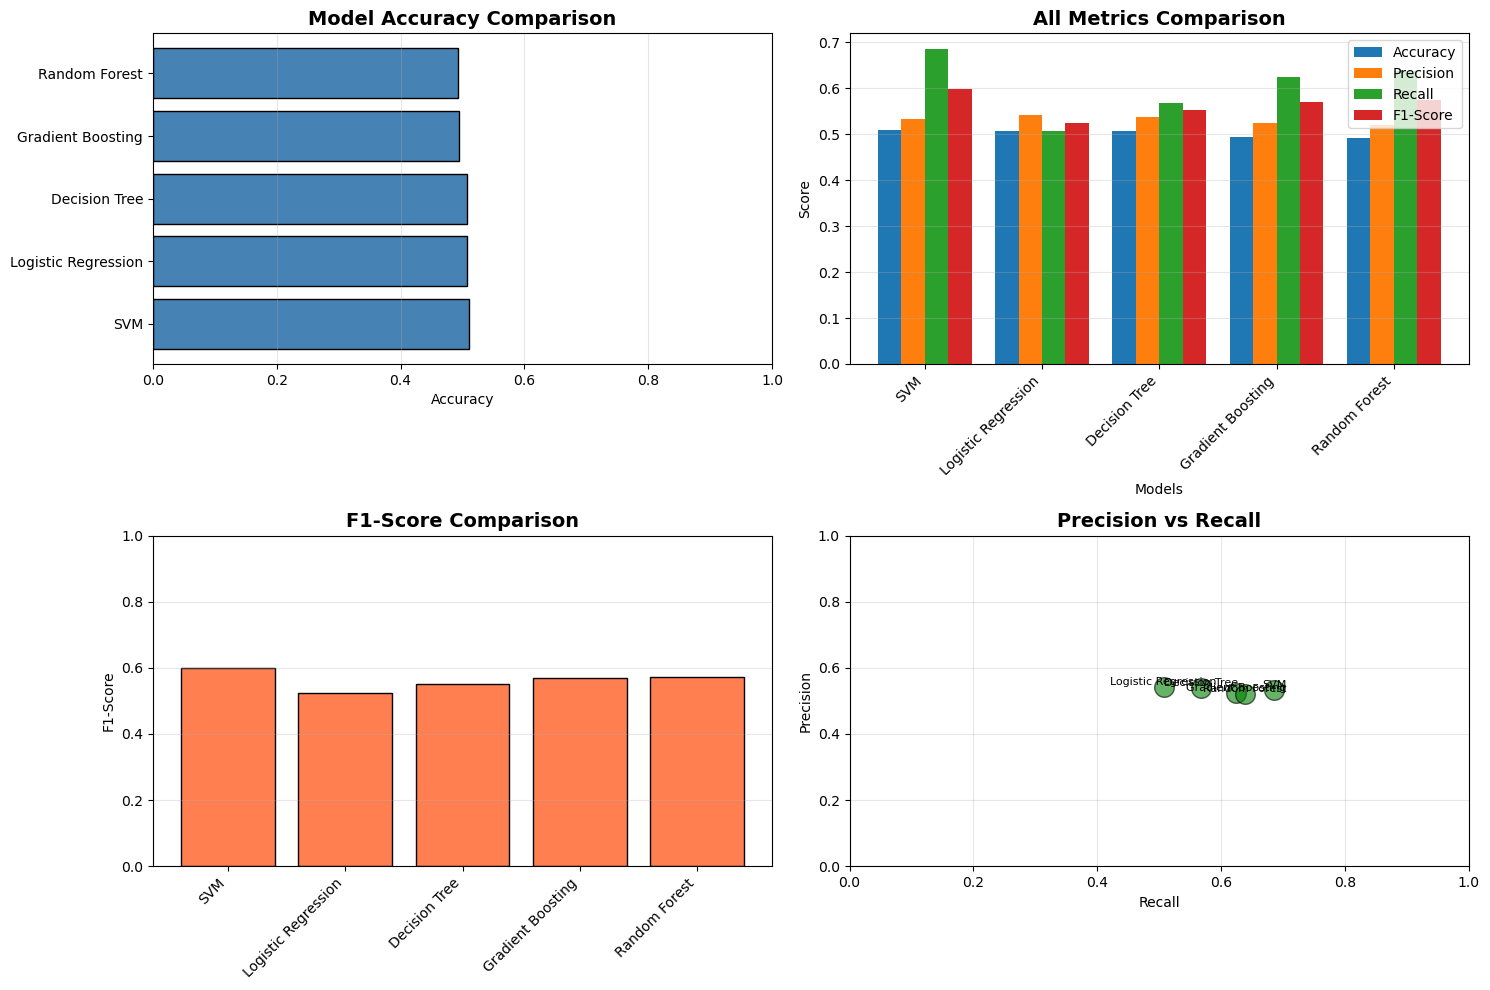

In [10]:
print("\n" + "="*80)
print("VISUALIZING MODEL COMPARISON")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Accuracy comparison
axes[0, 0].barh(results_df['Model'], results_df['Accuracy'], color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xlim(0, 1)
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. All metrics comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    axes[0, 1].bar(x + i*width, results_df[metric], width, label=metric)

axes[0, 1].set_xlabel('Models')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('All Metrics Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x + width * 1.5)
axes[0, 1].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. F1-Score comparison
axes[1, 0].bar(results_df['Model'], results_df['F1-Score'], color='coral', edgecolor='black')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Precision vs Recall
axes[1, 1].scatter(results_df['Recall'], results_df['Precision'], s=200, alpha=0.6, c='green', edgecolors='black')
for idx, row in results_df.iterrows():
    axes[1, 1].annotate(row['Model'], (row['Recall'], row['Precision']), 
                        fontsize=8, ha='center', va='bottom')
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Precision vs Recall', fontsize=14, fontweight='bold')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../plots/model_comparison.png', dpi=300)
print("✅ Saved: model_comparison.png")
plt.show()


### SELECT BEST MODEL

In [11]:
print("\n" + "="*80)
print("SELECTING BEST MODEL")
print("="*80)

# Get best model name
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"🏆 Best Model: {best_model_name}")
print(f"   Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")

# Retrain best model (it's already trained, but for clarity)
print("\n⏳ Retraining best model...")
best_model.fit(X_train, y_train)
print("✅ Best model retrained!")



SELECTING BEST MODEL
🏆 Best Model: SVM
   Accuracy: 0.5101

⏳ Retraining best model...
✅ Best model retrained!


### DETAILED EVALUATION OF BEST MODEL

In [12]:
print("\n" + "="*80)
print(f"DETAILED EVALUATION: {best_model_name}")
print("="*80)

# Predictions
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n📊 Confusion Matrix:")
print(cm)

# Classification Report
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Down (0)', 'Up (1)']))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n📊 ROC-AUC Score: {roc_auc:.4f}")



DETAILED EVALUATION: SVM

📊 Confusion Matrix:
[[ 57 128]
 [ 67 146]]

📊 Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.46      0.31      0.37       185
      Up (1)       0.53      0.69      0.60       213

    accuracy                           0.51       398
   macro avg       0.50      0.50      0.48       398
weighted avg       0.50      0.51      0.49       398


📊 ROC-AUC Score: 0.4882


### VISUALIZE BEST MODEL PERFORMANCE


VISUALIZING BEST MODEL PERFORMANCE
✅ Saved: best_model_evaluation.png


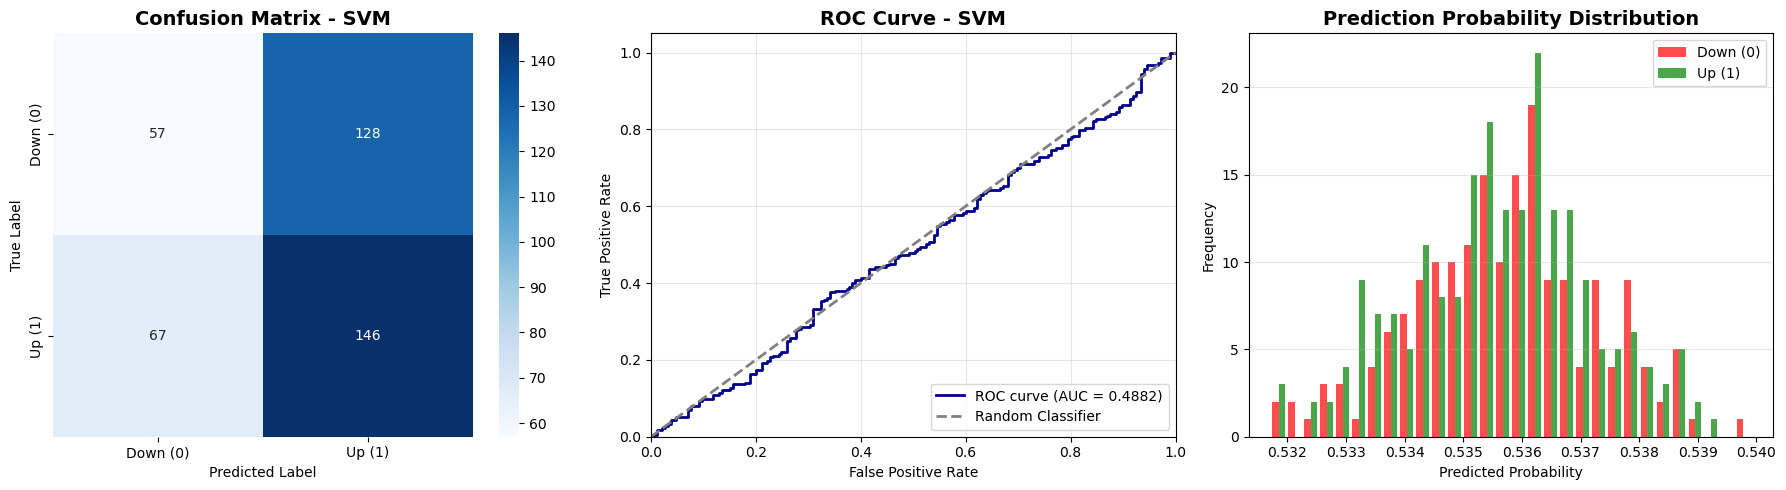

In [13]:
print("\n" + "="*80)
print("VISUALIZING BEST MODEL PERFORMANCE")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Down (0)', 'Up (1)'], 
            yticklabels=['Down (0)', 'Up (1)'])
axes[0].set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve - {best_model_name}', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

# 3. Prediction Distribution
axes[2].hist([y_pred_proba[y_test == 0], y_pred_proba[y_test == 1]], 
             bins=30, label=['Down (0)', 'Up (1)'], alpha=0.7, color=['red', 'green'])
axes[2].set_xlabel('Predicted Probability')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Prediction Probability Distribution', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/best_model_evaluation.png', dpi=300)
print("✅ Saved: best_model_evaluation.png")
plt.show()

### SAVE BEST MODEL

In [14]:
print("\n" + "="*80)
print("SAVING BEST MODEL")
print("="*80)

with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("✅ Best model saved to /models")

# Save model metadata
model_metadata = {
    'model_name': best_model_name,
    'accuracy': float(results_df.iloc[0]['Accuracy']),
    'precision': float(results_df.iloc[0]['Precision']),
    'recall': float(results_df.iloc[0]['Recall']),
    'f1_score': float(results_df.iloc[0]['F1-Score']),
    'roc_auc': float(roc_auc),
    'training_samples': int(len(X_train)),
    'testing_samples': int(len(X_test)),
    'features': int(X_train.shape[1])
}

with open('../models/model_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)
print("✅ Metadata saved to /models")

# Save all results
results_df.to_csv('../data/model_results.csv', index=False)
print("✅ Saved: model_results.csv")



SAVING BEST MODEL
✅ Best model saved to /models
✅ Metadata saved to /models
✅ Saved: model_results.csv


### FINAL SUMMARY

In [15]:
print("\n" + "="*80)
print("MODEL TRAINING COMPLETE! 🎉")
print("="*80)

summary = f"""
📊 TRAINING SUMMARY:

✅ Models Trained: {len(models)}
✅ Best Model: {best_model_name}

📈 Best Model Performance:
   • Accuracy:  {results_df.iloc[0]['Accuracy']:.4f}
   • Precision: {results_df.iloc[0]['Precision']:.4f}
   • Recall:    {results_df.iloc[0]['Recall']:.4f}
   • F1-Score:  {results_df.iloc[0]['F1-Score']:.4f}
   • ROC-AUC:   {roc_auc:.4f}

💾 Saved Files:
   ✓ best_model.pkl
   ✓ model_metadata.pkl
   ✓ model_results.csv
   ✓ model_comparison.png
   ✓ best_model_evaluation.png

🚀 Next Steps:
   1. Build Streamlit Application
   2. Deploy the model
   3. Make real-time predictions
"""

print(summary)
print("="*80)


MODEL TRAINING COMPLETE! 🎉

📊 TRAINING SUMMARY:

✅ Models Trained: 5
✅ Best Model: SVM

📈 Best Model Performance:
   • Accuracy:  0.5101
   • Precision: 0.5328
   • Recall:    0.6854
   • F1-Score:  0.5996
   • ROC-AUC:   0.4882

💾 Saved Files:
   ✓ best_model.pkl
   ✓ model_metadata.pkl
   ✓ model_results.csv
   ✓ model_comparison.png
   ✓ best_model_evaluation.png

🚀 Next Steps:
   1. Build Streamlit Application
   2. Deploy the model
   3. Make real-time predictions

